# E009 — Per-feature importance (LightGBM SHAP and permutation)

**Hypotheses:** H2, H7, H8 ([docs/hypotheses.md](../../docs/hypotheses.md))

**Result:** the publisher (app, site) and genre carry most of the signal; character ID is *used* but replaceable by genre (E005), conversation features and character age are within noise.

**Question:** Within the groups the ablations kept, which individual features does a model rely on, and do the dropped ones look different feature by feature?

**Method:** One LightGBM (tuned config) on train with every non-text group, including character ID and conversation. On the validation day: mean |SHAP| (TreeSHAP, logit units, 50k rows) and the log-loss increase when each feature is shuffled, with a 95 % hour-block bootstrap CI. Selection stays with the group ablations (E005): a used feature can still be replaceable.

In [1]:
from charade.analysis.experiment import setup

ctx = setup()
f"mode: {'smoke (fixture, tiny model)' if ctx.smoke else 'full data'}"

'mode: full data'

In [2]:
import matplotlib.pyplot as plt
import polars as pl

from charade.analysis import importance

table = importance.run(ctx.settings, ctx.data_dir, ctx.reports / "models")
table.with_columns(pl.col(pl.Float64).round(5))

feature,group,mean_abs_shap,permutation_delta,ci_low,ci_high
str,str,f64,f64,f64,f64
"""app_id""","""context""",0.19242,0.01459,0.01295,0.01659
"""site_id""","""context""",0.16263,0.01303,0.01225,0.01397
"""site_domain""","""context""",0.13123,0.00857,0.00785,0.00934
"""genre""","""character_meta""",0.09587,0.00731,0.00659,0.008
"""device_model""","""device""",0.11945,0.00419,0.00376,0.00468
…,…,…,…,…,…
"""creator_type""","""character_meta""",0.0002,0.0,-0.0,0.0
"""log_character_age_days""","""character_meta""",0.00306,-0.00001,-0.00003,0.00001
"""turn_position""","""conversation""",0.0022,-0.00001,-0.00004,0.00001


In [3]:
table.group_by("group").agg(pl.col("permutation_delta").sum()).sort("permutation_delta", descending=True)

group,permutation_delta
str,f64
"""context""",0.040458
"""character_meta""",0.00837
"""ad""",0.005096
"""device""",0.004507
"""user_history""",0.001387
"""character_id""",0.000991
"""conversation""",0.000002


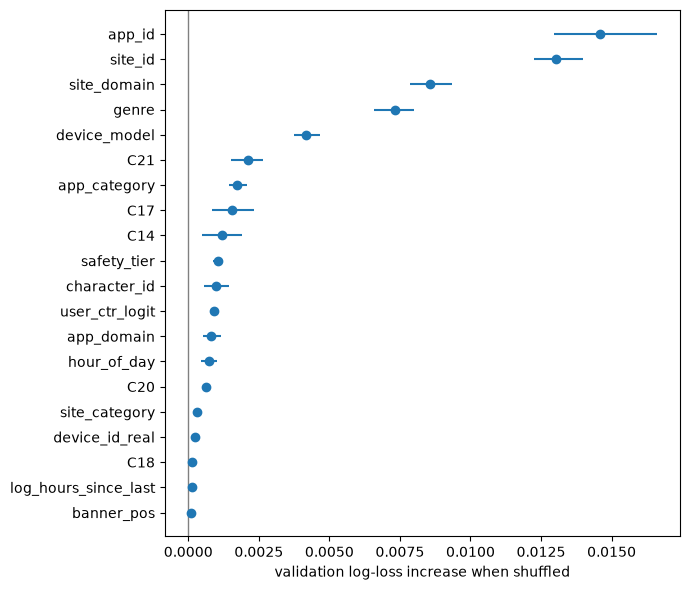

In [4]:
top = table.head(20).reverse()
_, ax = plt.subplots(figsize=(7, 6))
ax.errorbar(
    top["permutation_delta"],
    range(top.height),
    xerr=[top["permutation_delta"] - top["ci_low"], top["ci_high"] - top["permutation_delta"]],
    fmt="o",
)
ax.axvline(0, color="grey", lw=1)
ax.set_yticks(range(top.height), top["feature"].to_list())
ax.set_xlabel("validation log-loss increase when shuffled")
plt.tight_layout()
plt.show()

## Reading
- Context dominates: `app_id`, `site_id` and `site_domain` are the three most needed features. Where the ad runs matters more than anything about the ad or the user.
- H2: `genre` is the fourth most needed feature and the top character feature; `safety_tier` adds a little. `creator_type` is unused.
- Character ID is used (shuffling it costs about 0.001) yet removing the whole ID group costs nothing (E005): its signal is duplicated by genre and tier, the textbook case of "used but replaceable".
- H7: every conversation feature is within noise.
- H8: `log_character_age_days` is within noise on its own, which closes the gap left by ablating age only inside `character_meta`.
- User-history features are individually small; together they are the user-history group E005 keeps.

## Conclusion
The publisher (app, site) and genre carry most of the signal; character ID is used but replaceable by genre (E005), conversation features and character age are within noise.

**Decision:** No change to the shipped groups. Per-feature results support the group decisions and settle H8 for age.